# Perceptron Algorithm — Class Notes

The **Perceptron** is the simplest classification algorithm — and the building block of all neural networks.

It learns a **linear decision boundary** by updating weights *only when it makes a mistake*.

---

### Core idea

```
z   =  w · x         (dot product of weights and input)
ŷ   =  step(z)       (hard threshold: 1 if z > 0, else 0)

if wrong:  w ← w + lr · (y − ŷ) · x    (nudge weights)
if right:  w ← w  (no change — error = 0)
```

| | Perceptron | Logistic Regression |
|---|---|---|
| Activation | Step (hard 0/1) | Sigmoid (smooth 0–1) |
| Update rule | Mistake-driven | Gradient of log-loss |
| Output | Binary class | Probability |
| Convergence | Only if linearly separable | Always |
| Decision boundary | Linear | Linear |

## Step 0 — Imports & Data

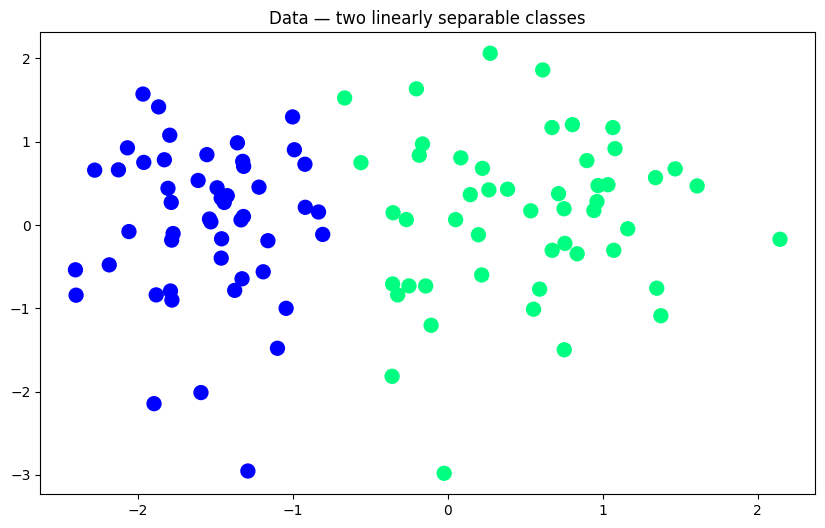

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=100,           # 100 data points
    n_features=2,            # 2 features → easy to plot on 2D scatter
    n_informative=1,         # only 1 feature actually separates the classes
    n_redundant=0,           # no duplicate features
    n_classes=2,             # binary: 0 or 1
    n_clusters_per_class=1,  # one tight blob per class
    class_sep=10,            # large gap → linearly separable data
    random_state=41,
    hypercube=False
)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.title('Data — two linearly separable classes')
plt.show()

## Step 1 — Step Function (Activation)

The perceptron uses a **hard threshold** — output is always exactly 0 or 1.

```
step(z) = 1   if z > 0
         = 0   otherwise
```

Unlike sigmoid (smooth S-curve), the step function is a binary on/off switch.

In [2]:
def step(z):
    return 1 if z > 0 else 0
    # z = dot product of weights and one sample's features
    # positive z → above the decision boundary → class 1
    # zero or negative → below → class 0

## Step 2 — Perceptron Training

### The bias trick — prepend a column of 1s

Instead of tracking the bias separately, we add a column of 1s to X:

```
X was (100, 2)  →  now (100, 3)
weights = [w₀, w₁, w₂]
             ↑
         w₀ automatically becomes the intercept (bias)
```

So `w · x = w₀·1 + w₁·x₁ + w₂·x₂`

---

### The perceptron update rule

```
w ← w + lr · (y − ŷ) · x
```

| Case | y − ŷ | Effect |
|---|---|---|
| Predicted correctly | 0 | No update |
| Should be 1, got 0 | +1 | Push weights toward x |
| Should be 0, got 1 | −1 | Push weights away from x |

In [3]:
def perceptron(X, y):

    # ── Bias trick: prepend a column of 1s ─────────────────────────
    X = np.insert(X, 0, 1, axis=1)
    # X.shape: (100, 2) → (100, 3)
    # axis=0 would insert a row; axis=1 inserts a column

    weights = np.ones(X.shape[1])   # initialise all weights to 1: [1, 1, 1]
    lr = 0.1

    for i in range(1000):

        # ── Pick one random sample (stochastic, like SGD) ───────────
        j = np.random.randint(0, 100)

        # ── Predict ─────────────────────────────────────────────────
        y_hat = step(np.dot(X[j], weights))
        # np.dot(X[j], weights) → scalar (z score)
        # step(z)               → 0 or 1

        # ── Update — only fires when y_hat ≠ y[j] ───────────────────
        weights = weights + lr * (y[j] - y_hat) * X[j]
        # error = 0  → weights unchanged (correct prediction)
        # error = +1 → weights += lr * X[j]  (was 0, should be 1)
        # error = -1 → weights -= lr * X[j]  (was 1, should be 0)

    return weights[0], weights[1:]  # intercept, feature weights

In [4]:
intercept_, coef_ = perceptron(X, y)
print('intercept:', intercept_)
print('coef_:    ', coef_)

intercept: 0.9
coef_:     [1.36952536 0.03681824]


## Step 3 — Convert Weights → Plotting Line

The decision boundary satisfies: &nbsp; `w₀ + w₁·x₁ + w₂·x₂ = 0`

Solving for x₂ (the y-axis on our plot):

```
x₂ = −(w₁/w₂)·x₁ − (w₀/w₂)
x₂ =    m · x₁   +   b
```

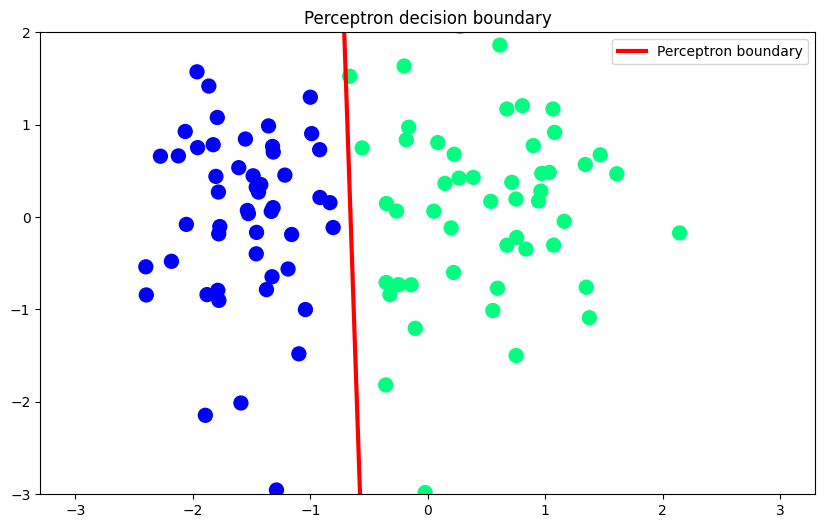

In [5]:
m = -(coef_[0] / coef_[1])     # slope     = −w₁/w₂
b = -(intercept_ / coef_[1])   # intercept = −w₀/w₂

x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color='red', linewidth=3, label='Perceptron boundary')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.title('Perceptron decision boundary')
plt.show()

## Step 4 — Animation: Watch the Boundary Learn

We record the slope `m` and intercept `b` after every weight update, then animate the line rotating into place.

In [6]:
def perceptron_animated(X, y):
    m_history, b_history = [], []

    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0, 100)
        y_hat = step(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

        # save current boundary at every step
        m_history.append(-(weights[1] / weights[2]))   # slope at step i
        b_history.append(-(weights[0] / weights[2]))   # intercept at step i

    return m_history, b_history

In [9]:

from matplotlib.animation import FuncAnimation

m_hist, b_hist = perceptron_animated(X, y)

fig, ax = plt.subplots(figsize=(9, 5))
x_i = np.arange(-3, 3, 0.1)

ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, x_i * m_hist[0] + b_hist[0], 'r-', linewidth=2)
plt.ylim(-3, 3)

def update(i):
    line.set_ydata(x_i * m_hist[i] + b_hist[i])
    ax.set_xlabel(f'step {i + 1}')

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
plt.show()

<IPython.core.display.Javascript object>

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


## Step 5 — Compare with Logistic Regression

Both find a **linear boundary**, but via different mechanisms:

| | Perceptron | Logistic Regression |
|---|---|---|
| Activation | `step()` — hard 0/1 | `sigmoid()` — smooth 0 to 1 |
| Loss | No explicit loss | Log-loss (cross-entropy) |
| Updates | Only on mistakes | Every sample, every epoch |
| Output | Binary class | Probability |

In [10]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X, y)

# lor.coef_ shape = (1, n_features) for binary classification → need [0]
m_lor = -(lor.coef_[0][0] / lor.coef_[0][1])
b_lor = -(lor.intercept_ / lor.coef_[0][1])

x_input = np.linspace(-3, 3, 100)

plt.figure(figsize=(10, 6))
plt.plot(x_input, m * x_input + b,     color='red',   linewidth=3, label='Perceptron')
plt.plot(x_input, m_lor * x_input + b_lor, color='black', linewidth=3, label='Logistic Regression')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)
plt.legend()
plt.title('Perceptron vs Logistic Regression boundary')
plt.show()

<IPython.core.display.Javascript object>

---

## Summary

| Concept | Detail |
|---|---|
| `np.insert(X,0,1,axis=1)` | Adds bias column — so w₀ becomes the intercept automatically |
| `step(z)` | Hard activation — output is exactly 0 or 1 |
| Update rule | `w += lr · (y − ŷ) · x` — only fires on mistakes |
| Decision boundary | `w₀ + w₁x₁ + w₂x₂ = 0` → rearranged to `x₂ = mx₁ + b` |
| Slope `m` | `−w₁/w₂` |
| Intercept `b` | `−w₀/w₂` |
| Convergence guarantee | Only when data is **linearly separable** |
| When to use instead | Use **Logistic Regression** if classes overlap |